<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/exoplanet_kepler8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exoplanet Discovery for Kepler-8**

In [36]:
# Lightkurve library installed, which is specifically designed to work with Kepler and TESS data.
!pip install lightkurve -q
import lightkurve as lk

[Kepler-8](https://en.m.wikipedia.org/wiki/Kepler-8) (KIC 6922244) is a star located in the constellation Lyra in the field of view of the Kepler Mission, a NASA-led operation tasked with discovering terrestrial planets. The star, which is slightly hotter, larger, and more massive than the Sun, has one gas giant in its orbit, Kepler-8b.

In [13]:
from astropy import units as u
import lightkurve as lk
import matplotlib.pyplot as plt
%matplotlib inline

In [37]:
search_result = lk.search_targetpixelfile("Kepler-8", author="Kepler", quarter=4, cadence="long")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 04,2010,Kepler,1800,kplr006922244,0.0


In [16]:
tpf = search_result.download()
first_cadence = tpf[0]
first_cadence

KeplerTargetPixelFile Object (ID: 6922244)

In [17]:
first_cadence.flux.value

array([[[          nan, 5.6079335e+00, 5.1491142e+01, 8.4241745e+01,
         3.0221334e+01],
        [4.4045620e+01, 7.6861229e+01, 1.1227759e+03, 3.2262029e+03,
         4.5486777e+02],
        [2.5911165e+01, 2.2907593e+02, 9.3626543e+03, 2.3606273e+04,
         1.2087750e+03],
        [4.0100830e+01, 8.8543927e+02, 1.7102118e+03, 2.6254871e+03,
         7.0796606e+02],
        [1.5719417e+02, 8.3713440e+02, 5.1021539e+02, 1.1501041e+03,
         1.8313370e+02]]], dtype='>f4')

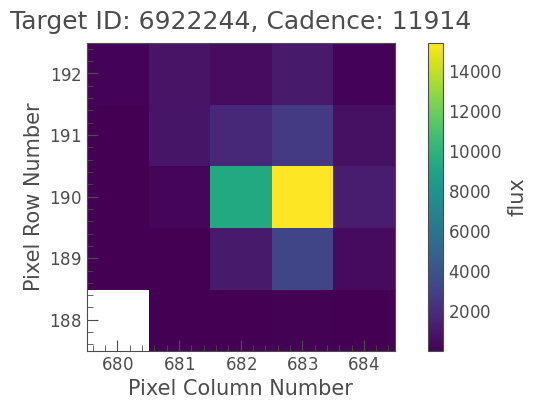

In [18]:
first_cadence.plot(column='flux');

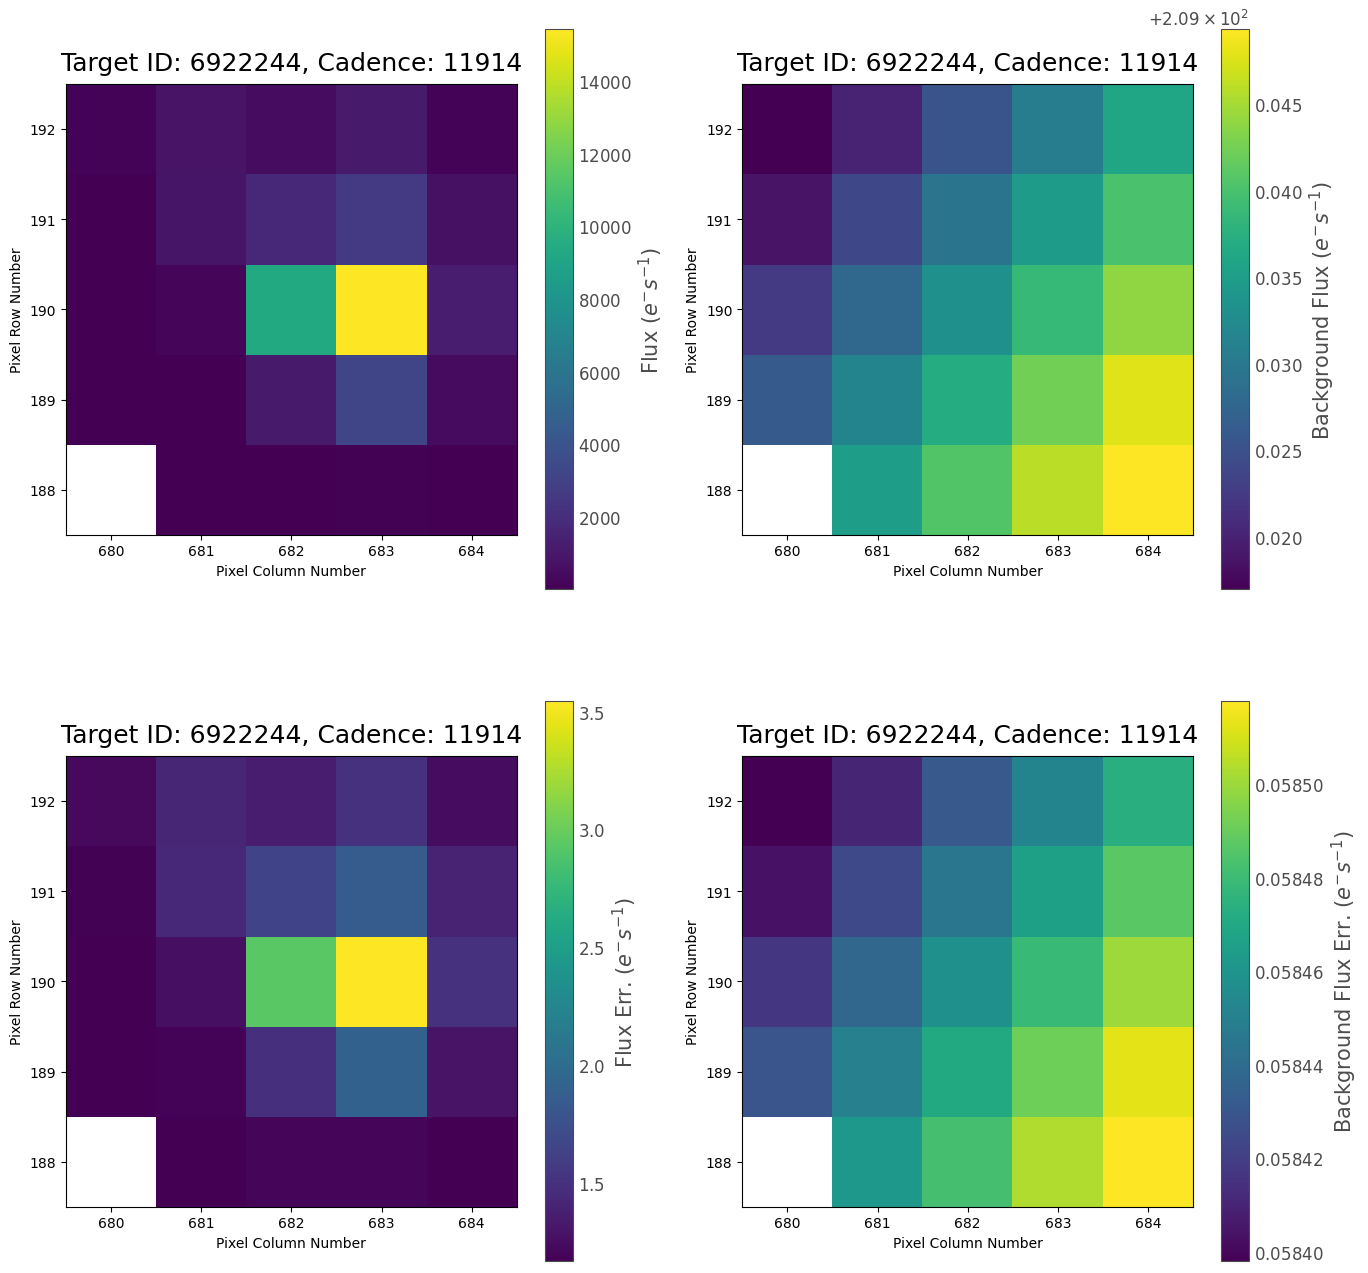

In [24]:
fig, axes = plt.subplots(2,2, figsize=(16,16))
first_cadence.plot(ax=axes[0,0], column='FLUX')
first_cadence.plot(ax=axes[0,1], column='FLUX_BKG')
first_cadence.plot(ax=axes[1,0], column='FLUX_ERR')
first_cadence.plot(ax=axes[1,1], column='FLUX_BKG_ERR');

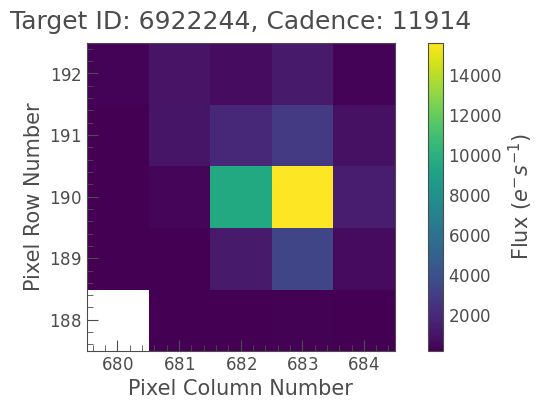

In [25]:
first_cadence.plot(bkg=True);

In [26]:
first_cadence.pipeline_mask

array([[False, False, False, False, False],
       [False, False,  True,  True, False],
       [False, False,  True,  True, False],
       [False,  True,  True,  True, False],
       [False, False, False,  True, False]])

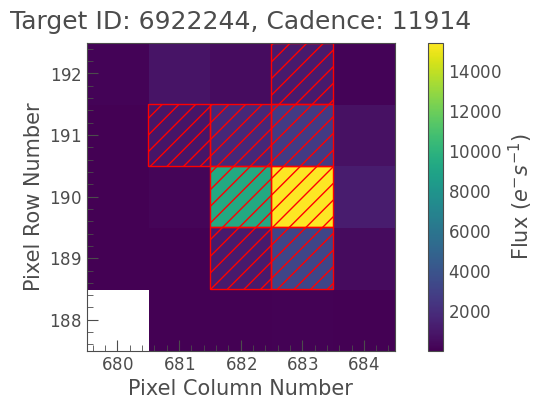

In [27]:
first_cadence.plot(aperture_mask=first_cadence.pipeline_mask);

In [38]:
lc = tpf.to_lightcurve()
lc

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float32,float32,float64,float64,int32,int32
352.37632485035283,43689.1484375,6.631562232971191,682.6803253766153,190.0726135828141,11914,0
352.3967580484896,43698.078125,6.631830215454102,682.679939392134,190.0724388237138,11915,8192
352.4376244455707,43694.10546875,6.6317877769470215,682.6796255144184,190.07267575992847,11917,16
352.45805764463876,43698.31640625,6.631948947906494,682.6797879974883,190.07249571597706,11918,0
352.4784908439324,43687.6484375,6.631504535675049,682.6792868410989,190.07246464783114,11919,0
352.4989240434661,43686.4765625,6.6314263343811035,682.6797248240034,190.07284002730125,11920,0
352.5193572433491,43692.59375,6.631662845611572,682.6797061866289,190.07275265635383,11921,0
352.53979034345684,43712.01953125,6.6356940269470215,682.6787299772047,190.07316832254241,11922,128


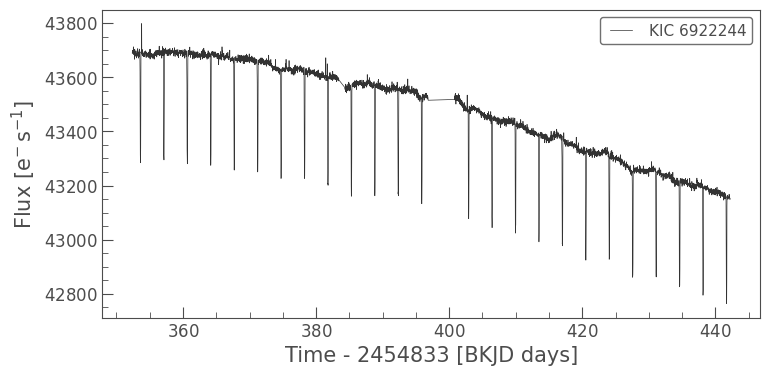

In [39]:
lc.plot();

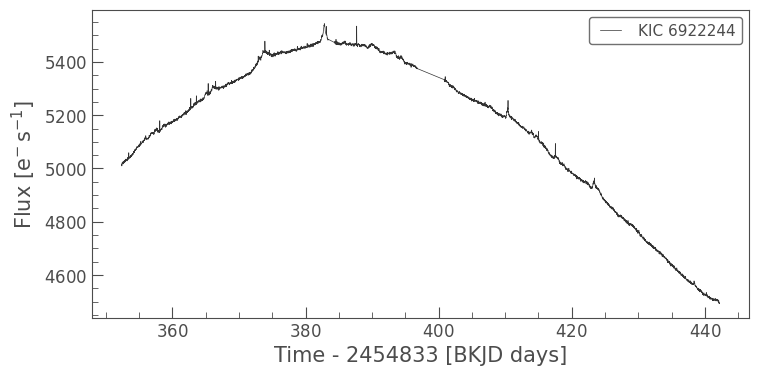

In [40]:
bkg = tpf.get_bkg_lightcurve()
bkg.plot();

In [41]:
from lightkurve import search_targetpixelfile

# First we open a Target Pixel File from MAST, this one is already cached from our previous tutorial!
tpf = search_targetpixelfile('KIC 6922244', author="Kepler", cadence="long", quarter=4).download()

# Then we convert the target pixel file into a light curve using the pipeline-defined aperture mask.
lc = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)

In [42]:
lc.meta['MISSION']

'Kepler'

In [43]:
lc.meta['QUARTER']

4

In [44]:
lc.time

<Time object: scale='tdb' format='bkjd' value=[352.37632485 352.39675805 352.43762445 ... 442.16263546 442.18306983
 442.2035041 ]>

In [45]:
lc.flux

<Quantity [43689.15 , 43698.08 , 43694.105, ..., 43155.8  , 43148.465,
           43151.562] electron / s>

In [46]:
lc.estimate_cdpp()

<Quantity 75.29876612 ppm>

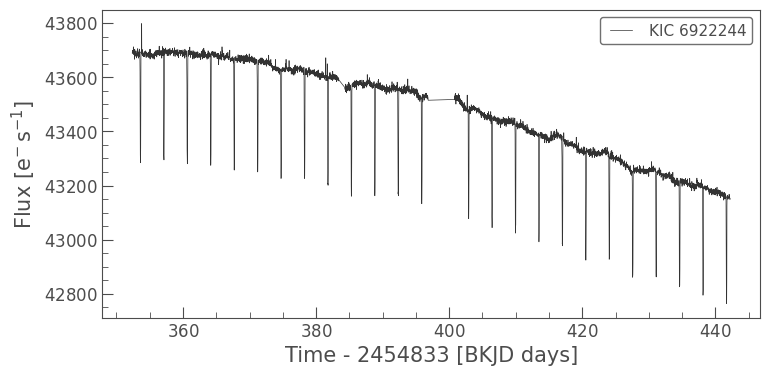

In [47]:
%matplotlib inline
lc.plot();

flatten(): Remove long term trends using a [Savitzky–Golay filter](https://en.m.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter)

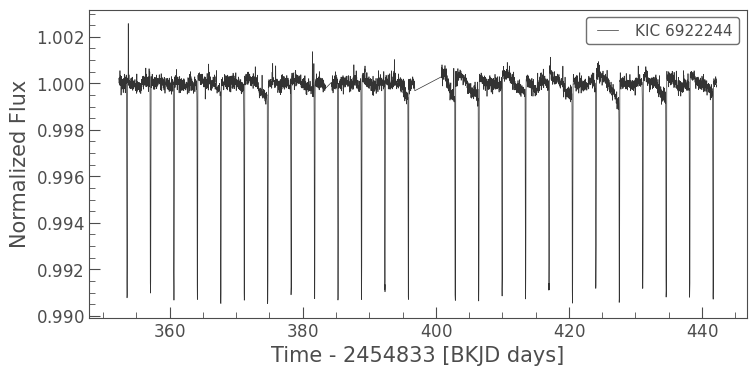

In [48]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot();

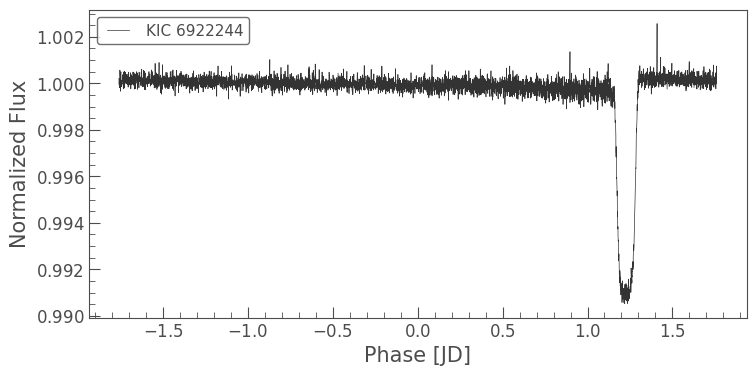

In [49]:
folded_lc = flat_lc.fold(period=3.5225) # fold(): Fold the data at a particular period
folded_lc.plot();

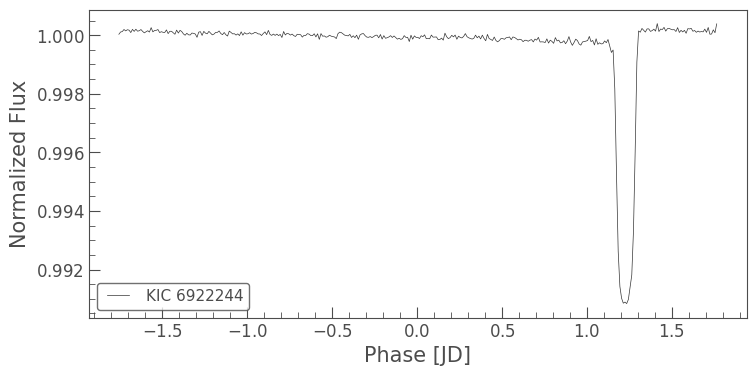

In [50]:
binned_lc = folded_lc.bin(time_bin_size=0.01) # bin() Reduce time resolution of array, taking average value in each bin
binned_lc.plot();

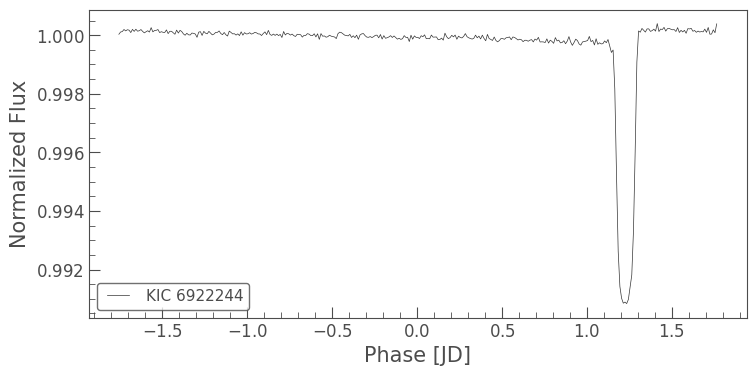

In [51]:
lc.remove_nans().flatten(window_length=401).fold(period=3.5225).bin(time_bin_size=0.01).plot();